 *Artificial Intelligence for Vision & NLP* &nbsp; | &nbsp;  *ATU Donegal - Postgrad Diploma in Big Data Analytics & Artificial Intelligence*

# Student Submisison 
Name           : Martin Law                         <br>
Student Number : L00203482                          <br>
Due Date       : Tuesday 12th May 2026              <br>
Assignment     : CA2                                <br>
Module         : AI for Vision and NLP              <br>
Course         : Postgraduate Diploma in Big Data Analytics and AI

## NLP and Vision Pipeline : High Level

This application will analyse scanned or photographed document images using a combined computer vision, OCR, NLP, and reporting pipeline.

The planned high level process is:

1. load scanned or photographed document images
2. preprocess images using OpenCV
3. extract text using Tesseract OCR
4. clean and process extracted text
5. extract NLP features such as tokens, stems, lemmas, keywords, and named entities
6. detect visual document features such as text blocks, tables, signatures, diagrams, figures, and form-like regions
7. combine the text and visual findings
8. export structured document summaries, annotated images, CSV files, and JSON reports

At this development stage, the notebook loads and displays the input document images. OCR, NLP processing, image preprocessing, segmentation, and feature detection will be added in later commits

In [1]:
# high-level pipeline placeholder for the first development stage

pipeline_steps = [
    "load scanned or photographed document images",
    "preprocess images using OpenCV",
    "extract text using Tesseract OCR",
    "clean and process extracted text",
    "extract NLP features",
    "detect visual document features",
    "combine text and image findings",
    "export structured document output"
]

for step_number, step_description in enumerate(pipeline_steps, start=1):
    print(f"{step_number}. {step_description}")

1. load scanned or photographed document images
2. preprocess images using OpenCV
3. extract text using Tesseract OCR
4. clean and process extracted text
5. extract NLP features
6. detect visual document features
7. combine text and image findings
8. export structured document output


# Initialisation
Perform pip installs(or use a requirements.txt) <br>
perform imports

## Install packages

In [2]:
# pip installs
# run this cell only if the required packages are not already instlal ed in the selected environment

# %pip install opencv-python pytesseract pandas numpy matplotlib scikit-learn nltk jupyter ipykernel

## Imports

In [3]:
# imports

from pathlib import Path
import platform
import json
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Support Functions

In [4]:
# support functions and project folders

PROJECT_DIR = Path.cwd()
INPUT_DIR = PROJECT_DIR / "data" / "input_documents"
OUTPUT_DIR = PROJECT_DIR / "outputs"

PREPROCESSED_DIR = OUTPUT_DIR / "preprocessed_images"
ANNOTATED_DIR = OUTPUT_DIR / "annotated_images"
JSON_DIR = OUTPUT_DIR / "json_reports"
CSV_DIR = OUTPUT_DIR / "csv_reports"

def create_project_folders():
    """ create the folder structure used by this notebook"""
    folders = [
        INPUT_DIR,
        OUTPUT_DIR,
        PREPROCESSED_DIR,
        ANNOTATED_DIR,
        JSON_DIR,
        CSV_DIR
    ]

    for folder in folders:
        folder.mkdir(parents=True, exist_ok=True)

    return folders

def list_input_documents():
    """return supported image files from the input document folder"""
    supported_extensions = [
        "*.jpg",
        "*.jpeg",
        "*.png",
        "*.bmp",
        "*.tif",
        "*.tiff"    
    ]

    image_paths = []

    for extension in supported_extensions:
        image_paths.extend(INPUT_DIR.glob(extension))

    return sorted(image_paths)

created_folders = create_project_folders()
input_documents = list_input_documents()

print("Project directory:", PROJECT_DIR)
print("Operating system:", platform.system())
print("Input directory:", INPUT_DIR)
print("Output directory:", OUTPUT_DIR)
print("Preprocessed image directory:", PREPROCESSED_DIR)
print("Number of input document images found:", len(input_documents))

for image_path in input_documents:
    print("-", image_path.name)

Project directory: /Users/martin/Desktop/Masters/AI for Vision and NLP/CA2/github/ca2-assignment-martinie
Operating system: Darwin
Input directory: /Users/martin/Desktop/Masters/AI for Vision and NLP/CA2/github/ca2-assignment-martinie/data/input_documents
Output directory: /Users/martin/Desktop/Masters/AI for Vision and NLP/CA2/github/ca2-assignment-martinie/outputs
Preprocessed image directory: /Users/martin/Desktop/Masters/AI for Vision and NLP/CA2/github/ca2-assignment-martinie/outputs/preprocessed_images
Number of input document images found: 1
- receipt1.png


# NLP

## Stage 2 NLP Plan

this section will later contain the OCR text cleaning and NLP processing.

Planned NLP functionality:

1. clean extracted OCR text
2. tokenise the text
3. remove stopwords
4. apply stemming
5. apply lemmatisation
6. extract keywords using TF-IDF
7. extract simple named entities such as dates, receipt numbers, IDs, names, and document references (if there)
8. identify references to tables, figures, diagrams, and signatures

there will be no NLP processing implemented in this commit

In [5]:
# NLP development status for this commit

nlp_development_status = {
    "ocr_text_cleaning": "planned",
    "tokenisation": "planned",
    "stopword_removal": "planned",
    "stemming": "planned",
    "lemmatisation": "planned",
    "tfidf_keyword_extraction": "planned",
    "entity_extraction": "planned",
    "figure_table_reference_detection": "planned"
}

nlp_development_status

{'ocr_text_cleaning': 'planned',
 'tokenisation': 'planned',
 'stopword_removal': 'planned',
 'stemming': 'planned',
 'lemmatisation': 'planned',
 'tfidf_keyword_extraction': 'planned',
 'entity_extraction': 'planned',
 'figure_table_reference_detection': 'planned'}

# Vision

This section adds the first real computer vision processing stage

The goal is to prepare scanned or photographed document images for later OCR and feature detection

The preprocessing steps are:

1. load the document image
2. convert it to grayscale
3. reduce noise using median blur
4. enhance contrast using CLAHE
5. apply Otsu thresholding
6. apply adaptive thresholding
7. detect edges using Canny edge detection
8. save the processed images for later stages

OCR is not performed in this stage. OCR will be added in the next dev cycle

In [6]:
# load and display input document images

input_documents = list_input_documents()

if len(input_documents) == 0:
    raise FileNotFoundError(
        f"No document images were found in {INPUT_DIR}. "
        "Add .jpg, .jpeg, .png, .bmp, .tif, or .tiff files before running this cell"
    )

loaded_documents = []

for image_path in input_documents:
    image = cv2.imread(str(image_path))

    if image is None:
        print(f"Could not load image: {image_path.name}")
        continue

    loaded_documents.append({
        "path": image_path,
        "filename": image_path.name,
        "image": image,
        "height": image.shape[0],
        "width": image.shape[1],
        "channels": image.shape[2] if len(image.shape) == 3 else 1
    })

print("Loaded document images:")

for document in loaded_documents:
    print(
        f"- {document['filename']} "
        f"({document['width']} x {document['height']}, "
        f"{document['channels']} channel(s))"
    )

Loaded document images:
- receipt1.png (1288 x 2248, 3 channel(s))


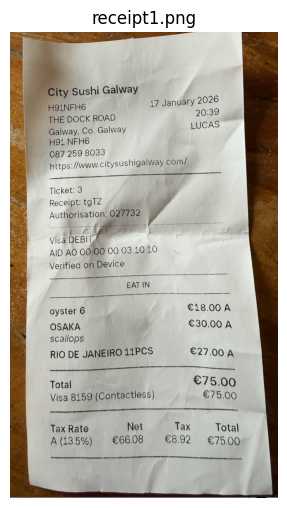

In [7]:
# display a sample of the loaded document images

documents_to_display = loaded_documents[:4]

plt.figure(figsize=(14, 10))

for index, document in enumerate(documents_to_display, start=1):
    image_rgb = cv2.cvtColor(document["image"], cv2.COLOR_BGR2RGB)

    plt.subplot(2, 2, index)
    plt.imshow(image_rgb)
    plt.axis("off")
    plt.title(document["filename"])

plt.tight_layout()
plt.show()

In [8]:
# OpenCV preprocessing functions

def preprocess_document_image(image):
    """Apply basic OpenCV preprocessing steps to a document image."""
    if image is None:
        raise ValueError("Cannot preprocess an empty image.")

    # convert from colour to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # reduce small noise while keeping text edges reasonably sharp
    denoised = cv2.medianBlur(gray, 3)

    # improve local contrast, useful for photographed documents with uneven lighting
    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )
    enhanced = clahe.apply(denoised)

    # global thresholding using Otsu's method
    _, otsu_threshold = cv2.threshold(
        enhanced,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    # adaptive thresholding handles uneven lighting better than a single global threshold
    adaptive_threshold = cv2.adaptiveThreshold(
        enhanced,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        31,
        15
    )

    # edge detection is useful later for detecting boxes, tables, and page boundaries
    edges = cv2.Canny(
        enhanced,
        threshold1=50,
        threshold2=150
    )

    return {
        "gray": gray,
        "denoised": denoised,
        "enhanced": enhanced,
        "otsu_threshold": otsu_threshold,
        "adaptive_threshold": adaptive_threshold,
        "edges": edges
    }


In [9]:
# preprocess all loaded document images and save the results

if "loaded_documents" not in globals():
    raise NameError("loaded_documents does not exist. Run the image loading cell before this cell.")

if len(loaded_documents) == 0:
    raise ValueError("No loaded documents are available for preprocessing.")

preprocessed_documents = []

for document in loaded_documents:
    filename_stem = Path(document["filename"]).stem

    processed_images = preprocess_document_image(document["image"])

    output_paths = {}

    for processing_name, processed_image in processed_images.items():
        output_path = PREPROCESSED_DIR / f"{filename_stem}_{processing_name}.png"
        cv2.imwrite(str(output_path), processed_image)
        output_paths[processing_name] = output_path

    preprocessed_documents.append({
        "filename": document["filename"],
        "original_image": document["image"],
        "processed_images": processed_images,
        "output_paths": output_paths
    })

print("Preprocessed document images saved:")

for document in preprocessed_documents:
    print(f"- {document['filename']}")

    for processing_name, output_path in document["output_paths"].items():
        print(f"  {processing_name}: {output_path.name}")


Preprocessed document images saved:
- receipt1.png
  gray: receipt1_gray.png
  denoised: receipt1_denoised.png
  enhanced: receipt1_enhanced.png
  otsu_threshold: receipt1_otsu_threshold.png
  adaptive_threshold: receipt1_adaptive_threshold.png
  edges: receipt1_edges.png


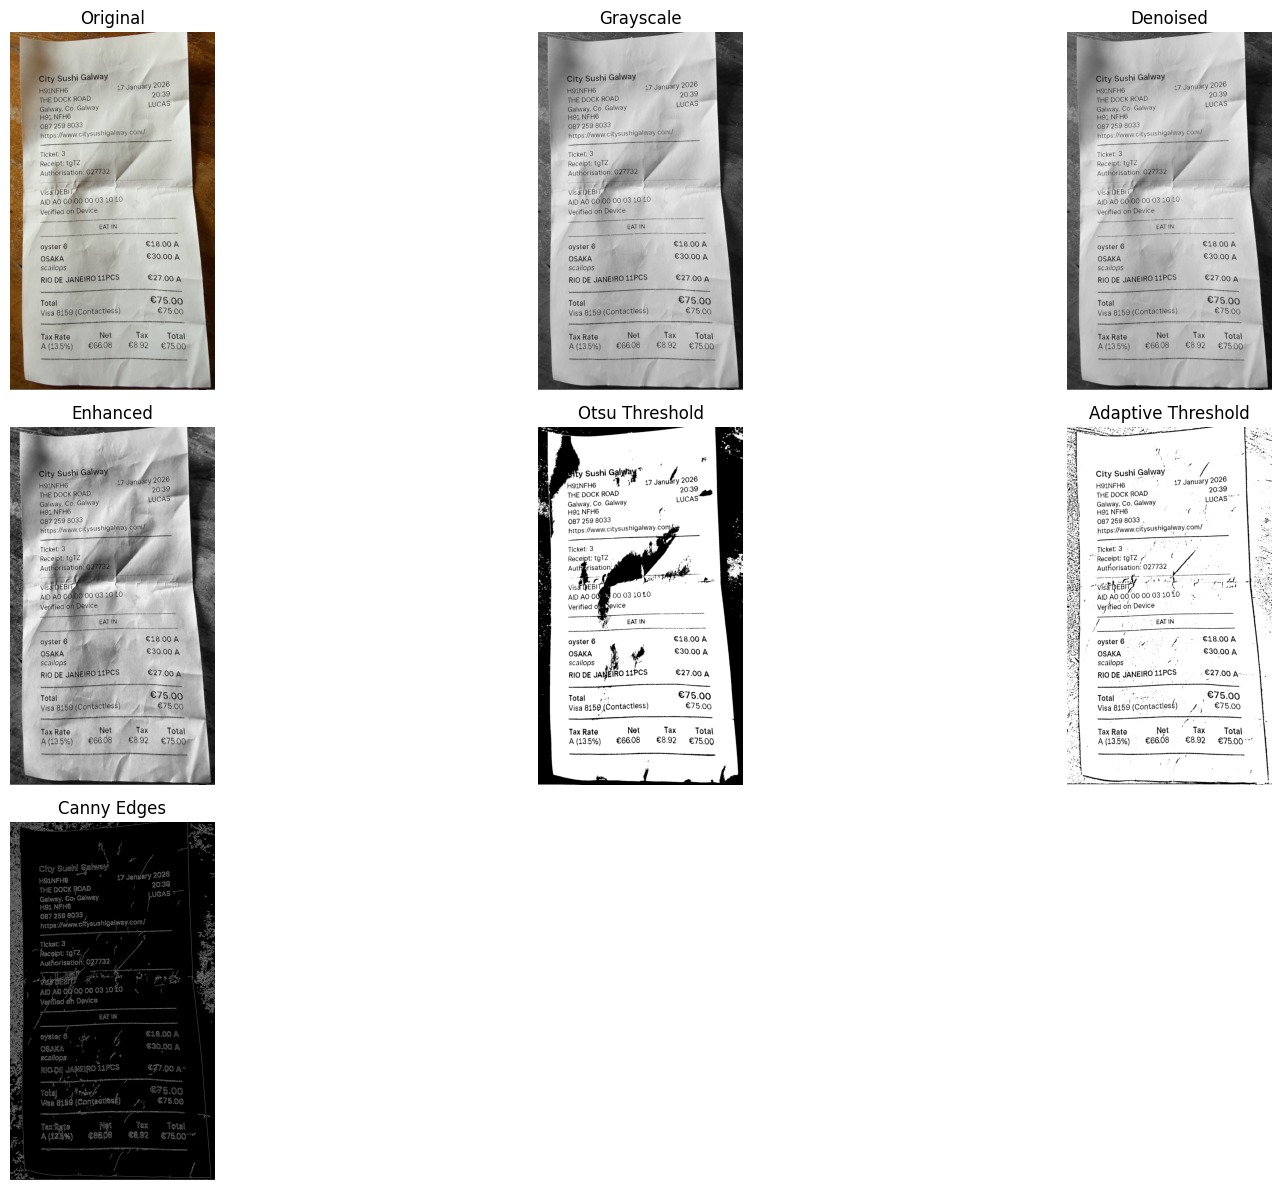

Displayed preprocessing results for: receipt1.png


In [10]:
# display preprocessing results for the first document

example_document = preprocessed_documents[0]

original_rgb = cv2.cvtColor(example_document["original_image"], cv2.COLOR_BGR2RGB)

display_images = [
    ("Original", original_rgb, None),
    ("Grayscale", example_document["processed_images"]["gray"], "gray"),
    ("Denoised", example_document["processed_images"]["denoised"], "gray"),
    ("Enhanced", example_document["processed_images"]["enhanced"], "gray"),
    ("Otsu Threshold", example_document["processed_images"]["otsu_threshold"], "gray"),
    ("Adaptive Threshold", example_document["processed_images"]["adaptive_threshold"], "gray"),
    ("Canny Edges", example_document["processed_images"]["edges"], "gray")
]

plt.figure(figsize=(16, 12))

for index, (title, image, colour_map) in enumerate(display_images, start=1):
    plt.subplot(3, 3, index)
    plt.imshow(image, cmap=colour_map)
    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.show()

print("Displayed preprocessing results for:", example_document["filename"])


# Multi-modal

## Stage 3 Multi-modal Plan

This section will combine OCR, NLP, and computer vision outputs into one document level result

The final multi-modal result will include:

1. document name
2. OCR confidence
3. extracted raw text
4. cleaned text
5. tokens, stems, lemmas, and keywords
6. detected text blocks
7. detected tables
8. detected signature regions
9. detected diagram or figure regions
10. relationships between text and visual objects, such as references to figures or tables
11. structured JSON and CSV reports
12. annotated document images

No multi-modal integration is implemented in this commit, this commit only adds image preprocessing outputs that will be used by later OCR and feature detection stages

In [11]:
# multi-modal development status for this commit

multimodal_development_status = {
    "ocr_to_layout_mapping": "planned",
    "section_categorisation": "planned",
    "table_text_extraction": "planned",
    "diagram_reference_detection": "planned",
    "visual_feature_summary": "planned",
    "json_report_generation": "planned",
    "csv_summary_generation": "planned",
    "annotated_image_generation": "planned"
}

multimodal_development_status

{'ocr_to_layout_mapping': 'planned',
 'section_categorisation': 'planned',
 'table_text_extraction': 'planned',
 'diagram_reference_detection': 'planned',
 'visual_feature_summary': 'planned',
 'json_report_generation': 'planned',
 'csv_summary_generation': 'planned',
 'annotated_image_generation': 'planned'}

# Final Output

In [12]:
# final output summary for this development stage

# stage_2_summary = {
#     "stage": "document image loading",
#     "template_followed": True,
#     "input_documents_found": len(input_documents),
#     "successfully_loaded_documents": len(loaded_documents),
#     "input_document_names": [document["filename"] for document in loaded_documents],
#     "next_stage": "add grayscale conversion, denoising, and threshold preprocessing"
# }
#print(json.dumps(stage_2_summary, indent=4))

stage_3_summary = {
    "stage": "OpenCV image preprocessing and enhancement",
    "template_followed": True,
    "input_documents_found": len(input_documents),
    "successfully_loaded_documents": len(loaded_documents),
    "preprocessed_documents": len(preprocessed_documents),
    "preprocessing_steps": [
        "grayscale conversion",
        "median blur denoising",
        "CLAHE contrast enhancement",
        "Otsu thresholding",
        "adaptive thresholding",
        "Canny edge detection"
    ],
    "preprocessed_output_directory": str(PREPROCESSED_DIR),
    "next_stage": "add Tesseract OCR extraction and OCR confidence reporting"
}

print(json.dumps(stage_3_summary, indent=4))


{
    "stage": "OpenCV image preprocessing and enhancement",
    "template_followed": true,
    "input_documents_found": 1,
    "successfully_loaded_documents": 1,
    "preprocessed_documents": 1,
    "preprocessing_steps": [
        "grayscale conversion",
        "median blur denoising",
        "CLAHE contrast enhancement",
        "Otsu thresholding",
        "adaptive thresholding",
        "Canny edge detection"
    ],
    "preprocessed_output_directory": "/Users/martin/Desktop/Masters/AI for Vision and NLP/CA2/github/ca2-assignment-martinie/outputs/preprocessed_images",
    "next_stage": "add Tesseract OCR extraction and OCR confidence reporting"
}


In [13]:
# development notes
# major commit 3 adds the first OpenCV image preprocessing stage
# the original image is converted to grayscale, denoised, contrast-enhanced, thresholded, and edge-detected
# the processed images are saved to outputs/preprocessed_images
# OCR is intentionally left for the next commit